#**Spark analysis**

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, sum as spark_sum, when, lit
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression
from pyspark.ml.stat import Correlation
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
spark = SparkSession.builder \
    .appName("Krisha.kz Real Estate Analysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [3]:
df = spark.read.csv('krisha_clean.csv', header=True)


In [4]:
print("=== Data Overview ===")
df.printSchema()
print(f"Total records: {df.count()}")

=== Data Overview ===
root
 |-- id: string (nullable = true)
 |-- price: string (nullable = true)
 |-- room_count: string (nullable = true)
 |-- quadrature: string (nullable = true)
 |-- floor_text: string (nullable = true)
 |-- floor: string (nullable = true)
 |-- region_text: string (nullable = true)
 |-- region: string (nullable = true)
 |-- year: string (nullable = true)
 |-- flat_toilet: string (nullable = true)
 |-- flat_balcony: string (nullable = true)
 |-- flat_balcony_g: string (nullable = true)
 |-- flat_door: string (nullable = true)
 |-- inet_type: string (nullable = true)
 |-- flat_parking: string (nullable = true)
 |-- live_furniture: string (nullable = true)
 |-- flat_flooring: string (nullable = true)
 |-- ceiling: string (nullable = true)
 |-- url: string (nullable = true)

Total records: 31206


In [5]:
df_clean = df.filter(
    (col('price') > 0) &
    (col('price') < 1000000000) &
    (col('quadrature') > 0) &
    (col('quadrature') < 1000)
)

In [6]:
df_clean = df_clean.withColumn('price', col('price').cast(DoubleType()))
df_clean = df_clean.withColumn('quadrature', col('quadrature').cast(DoubleType()))
df_clean = df_clean.withColumn('room_count', col('room_count').cast(IntegerType()))
df_clean = df_clean.withColumn('floor', col('floor').cast(IntegerType()))
df_clean = df_clean.withColumn('ceiling', col('ceiling').cast(DoubleType()))


In [7]:
df_clean = df_clean.withColumn('price_per_m2', col('price') / col('quadrature'))

In [8]:
print("\n=== Basic Statistics ===")
df_clean.select('price', 'quadrature', 'price_per_m2', 'room_count').describe().show()



=== Basic Statistics ===
+-------+-------------------+-----------------+------------------+------------------+
|summary|              price|       quadrature|      price_per_m2|        room_count|
+-------+-------------------+-----------------+------------------+------------------+
|  count|              31205|            31205|             31205|             31205|
|   mean|5.857783940644128E7|69.91603909629868| 791448.7069941377|2.3118410511136034|
| stddev| 5.94616502295575E7|44.59330529657086|  273459.076219435|1.0161570459435314|
|    min|           600000.0|             10.0|20689.655172413793|                 1|
|    max|       9.99999999E8|            999.0| 5434782.608695652|                12|
+-------+-------------------+-----------------+------------------+------------------+



In [9]:
df_clean.show()

+---+-------+----------+----------+----------+-----+-----------------+------+----+-------------+--------------------+--------------+-------------+---------+--------------------+--------------+-------------+-------+--------------------+------------------+
| id|  price|room_count|quadrature|floor_text|floor|      region_text|region|year|  flat_toilet|        flat_balcony|flat_balcony_g|    flat_door|inet_type|        flat_parking|live_furniture|flat_flooring|ceiling|                 url|      price_per_m2|
+---+-------+----------+----------+----------+-----+-----------------+------+----+-------------+--------------------+--------------+-------------+---------+--------------------+--------------+-------------+-------+--------------------+------------------+
|  1|  4.6E7|         3|     134.0|     13/16|    0|Наурызбайский р-н|  0.11|2012|      no_info|              лоджия|            да|металлическая|     ADSL|             паркинг|      частично|      no_info|    2.8|https://krisha.kz...|

##Average price by region


In [10]:
print("\n=== Average Price by Region ===")
region_stats = df_clean.groupBy('region_text') \
    .agg(
        avg('price').alias('avg_price'),
        avg('price_per_m2').alias('avg_price_per_m2'),
        count('*').alias('count')
    ) \
    .orderBy(col('avg_price').desc())
region_stats.show(20)
region_stats.write.csv("region_stats", header=True, mode='overwrite')


=== Average Price by Region ===
+-----------------+--------------------+------------------+-----+
|      region_text|           avg_price|  avg_price_per_m2|count|
+-----------------+--------------------+------------------+-----+
|    Медеуский р-н|1.0634712653828073E8| 984316.3617705834| 2978|
|Бостандыкский р-н|  8.28249461511492E7| 959483.9134918642| 7701|
|           Алматы| 5.751697027457627E7| 796614.5879277125|  590|
|  Алмалинский р-н| 5.283788678897796E7| 828715.7226178441| 4990|
|   Ауэзовский р-н| 4.417892063723948E7|  723461.284634718| 5086|
|Наурызбайский р-н| 4.163377167074702E7| 647574.5094216508| 3186|
| Алматинская обл.|4.0966350925925925E7|470929.53781938774|   27|
|   Алатауский р-н|  3.32196494101467E7| 609353.0659063903| 3272|
|   Жетысуский р-н| 3.281773416161616E7| 609505.2660819832| 1584|
|  Турксибский р-н|3.1639026151312117E7| 590123.9221372188| 1791|
+-----------------+--------------------+------------------+-----+



##Average price by room count


In [11]:
print("\n=== Average Price by Room Count ===")
room_stats = df_clean.groupBy('room_count') \
    .agg(
        avg('price').alias('avg_price'),
        avg('quadrature').alias('avg_quadrature'),
        avg('price_per_m2').alias('avg_price_per_m2'),
        count('*').alias('count')
    ) \
    .orderBy('room_count')

room_stats.show()
room_stats.write.csv("room_stats", header=True, mode='overwrite')



=== Average Price by Room Count ===
+----------+--------------------+------------------+------------------+-----+
|room_count|           avg_price|    avg_quadrature|  avg_price_per_m2|count|
+----------+--------------------+------------------+------------------+-----+
|         1| 2.714549419426934E7| 36.45114613180516|  751116.998385299| 6980|
|         2| 4.423082550926402E7|56.821152856407615| 775081.1367758858|11658|
|         3| 6.813746178096452E7| 83.48257913745485| 788056.7735835242| 9414|
|         4|1.2284556071119843E8|126.59764243614931| 925146.0347939318| 2545|
|         5|2.3972902991794872E8|220.50512820512822| 1065011.493094211|  390|
|         6| 2.954426084811321E8|275.45283018867923|1038810.8007775885|  106|
|         7|4.0015271277380955E8| 361.3452380952381|1122288.5519574957|   84|
|         8|        2.87242635E8|            357.25| 805712.8037648969|   16|
|         9|              4.77E8|             395.6|1224760.3368146662|    5|
|        10| 3.933333333333

##feature importance analysis


In [12]:
print("\n=== Feature Importance Analysis ===")
df_ml = df_clean.filter(
    (col('room_count').isNotNull()) &
    (col('quadrature').isNotNull()) &
    (col('floor').isNotNull()) &
    (col('ceiling').isNotNull())
).fillna(0)

df_ml = df_ml.withColumn('has_parking',
                         when(col('flat_parking') != 'NULL', 1).otherwise(0))
df_ml = df_ml.withColumn('has_furniture',
                         when(col('live_furniture') != 'NULL', 1).otherwise(0))
df_ml = df_ml.withColumn('has_internet',
                         when(col('inet_type') != 'NULL', 1).otherwise(0))


feature_cols = ['room_count', 'quadrature', 'floor', 'ceiling',
                'has_parking', 'has_furniture', 'has_internet']

assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_ml = assembler.transform(df_ml)

lr = LinearRegression(featuresCol='features', labelCol='price', maxIter=10)
lr_model = lr.fit(df_ml)

print(f"RMSE: {lr_model.summary.rootMeanSquaredError}")
print(f"R2: {lr_model.summary.r2}")
print(f"\nCoefficients:")
for feature, coef in zip(feature_cols, lr_model.coefficients):
    print(f"  {feature}: {coef}")


=== Feature Importance Analysis ===
RMSE: 34794254.178722724
R2: 0.708159138377193

Coefficients:
  room_count: -5763009.862754612
  quadrature: 1251170.1831653656
  floor: -786866.2555190682
  ceiling: 1760694.0987303795
  has_parking: 0.0
  has_furniture: 0.0
  has_internet: 0.0


In [13]:
numeric_cols = ['price', 'room_count', 'quadrature', 'floor', 'ceiling', 'price_per_m2']
df_numeric = df_clean.select(numeric_cols).fillna(0)


##Correlation Matrix


In [14]:
pdf = df_numeric.toPandas()
correlation_matrix = pdf.corr()
print(correlation_matrix)


                 price  room_count  quadrature     floor   ceiling  \
price         1.000000    0.612738    0.836569 -0.009461  0.150227   
room_count    0.612738    1.000000    0.779630  0.018018  0.077100   
quadrature    0.836569    0.779630    1.000000  0.003217  0.143731   
floor        -0.009461    0.018018    0.003217  1.000000 -0.088547   
ceiling       0.150227    0.077100    0.143731 -0.088547  1.000000   
price_per_m2  0.651705    0.175113    0.265940 -0.057138  0.131454   

              price_per_m2  
price             0.651705  
room_count        0.175113  
quadrature        0.265940  
floor            -0.057138  
ceiling           0.131454  
price_per_m2      1.000000  


##Computing score

In [15]:
region_price_rank = df_clean.groupBy('region_text') \
    .agg(avg('price_per_m2').alias('region_avg_price'))

from pyspark.sql.window import Window

max_quad = df_clean.agg({'quadrature': 'max'}).collect()[0][0]
df_scored = df_clean.withColumn('size_score', col('quadrature') / max_quad)

df_scored = df_scored.join(region_price_rank, 'region_text', 'left')

max_region_price = region_price_rank.agg({'region_avg_price': 'max'}).collect()[0][0]
df_scored = df_scored.withColumn('region_score',
                                 1 - (col('region_avg_price') / max_region_price))

df_scored = df_scored.withColumn('comfort_score',
    (when(col('inet_type') != 'NULL', 0.25).otherwise(0) +
     when(col('flat_parking') != 'NULL', 0.25).otherwise(0) +
     when(col('live_furniture') != 'NULL', 0.25).otherwise(0) +
     when(col('flat_balcony') != 'NULL', 0.25).otherwise(0))
)

df_scored = df_scored.withColumn('value_score',
    0.5 * col('size_score') +
    0.3 * col('region_score') +
    0.2 * col('comfort_score')
)

print("\n=== Top 20 Best Value Properties ===")
df_scored.select('price', 'room_count', 'quadrature', 'region_text',
                'price_per_m2', 'value_score') \
    .orderBy(col('value_score').desc()) \
    .show(20)


=== Top 20 Best Value Properties ===
+------------+----------+----------+-----------------+------------------+-------------------+
|       price|room_count|quadrature|      region_text|      price_per_m2|        value_score|
+------------+----------+----------+-----------------+------------------+-------------------+
|9.99999999E8|         7|     999.0|    Медеуский р-н|         1001001.0|                0.7|
|9.99999999E8|         7|     999.0|    Медеуский р-н|         1001001.0|                0.7|
|9.99999999E8|         7|     999.0|    Медеуский р-н|         1001001.0|                0.7|
|9.99999999E8|        12|     999.0|    Медеуский р-н|         1001001.0|                0.7|
|      5.15E8|         7|     781.0|    Медеуский р-н| 659411.0115236876|  0.590890890890891|
|8.69999999E8|         6|     650.0|Бостандыкский р-н| 1338461.536923077| 0.5328937604067205|
|       8.7E8|         7|     648.0|Бостандыкский р-н|1342592.5925925926| 0.5318927594057196|
|       3.3E8|        

In [16]:
df_scored.write.csv("scored_listings",
                    header=True, mode='overwrite')

In [17]:
print("\n=== Exporting data for visualization ===")
region_stats.toPandas().to_csv('region_stats.csv', index=False)
room_stats.toPandas().to_csv('room_stats.csv', index=False)
df_scored.select('price', 'quadrature', 'price_per_m2', 'room_count',
                'region_text', 'value_score').toPandas().to_csv('listings_sample.csv', index=False)



=== Exporting data for visualization ===


#**Visualization**


In [18]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [19]:
region_stats = pd.read_csv('region_stats.csv')
room_stats = pd.read_csv('room_stats.csv')
listings = pd.read_csv('listings_sample.csv')

## Visualization 1: Average Price per m² by Region

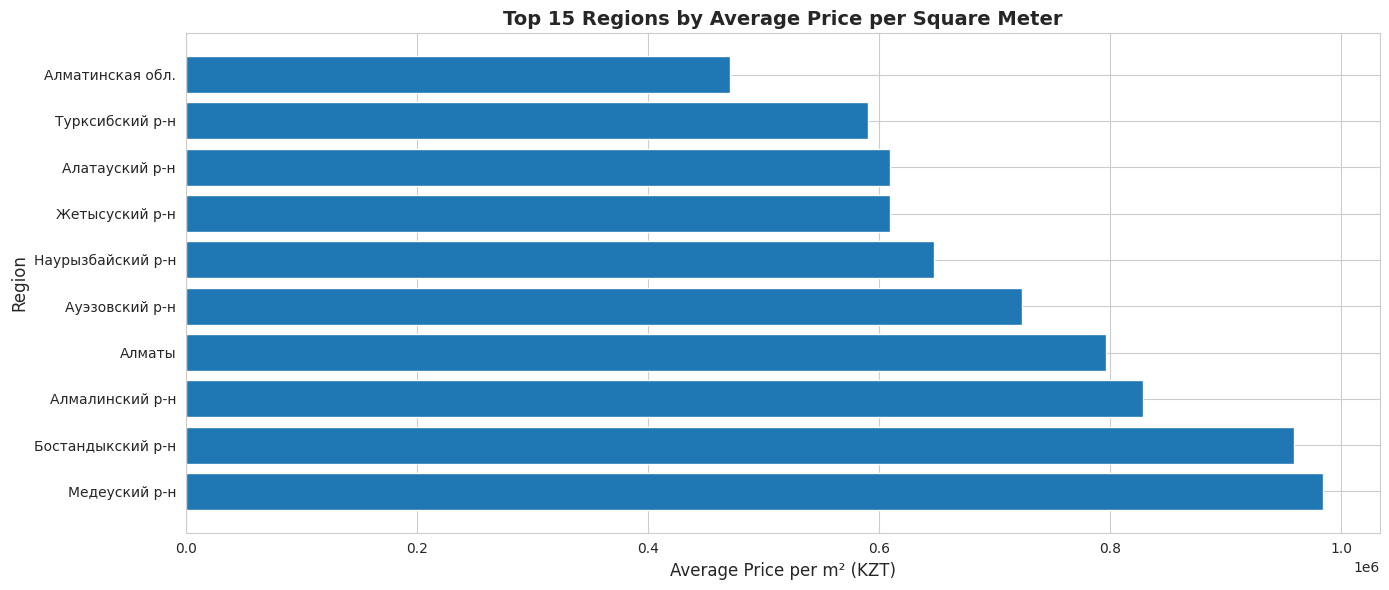

In [20]:
top_regions = region_stats.nlargest(15, 'avg_price_per_m2')
plt.figure(figsize=(14, 6))
plt.barh(top_regions['region_text'], top_regions['avg_price_per_m2'])
plt.xlabel('Average Price per m² (KZT)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.title('Top 15 Regions by Average Price per Square Meter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualization 2: Price vs Quadrature Scatter Plot

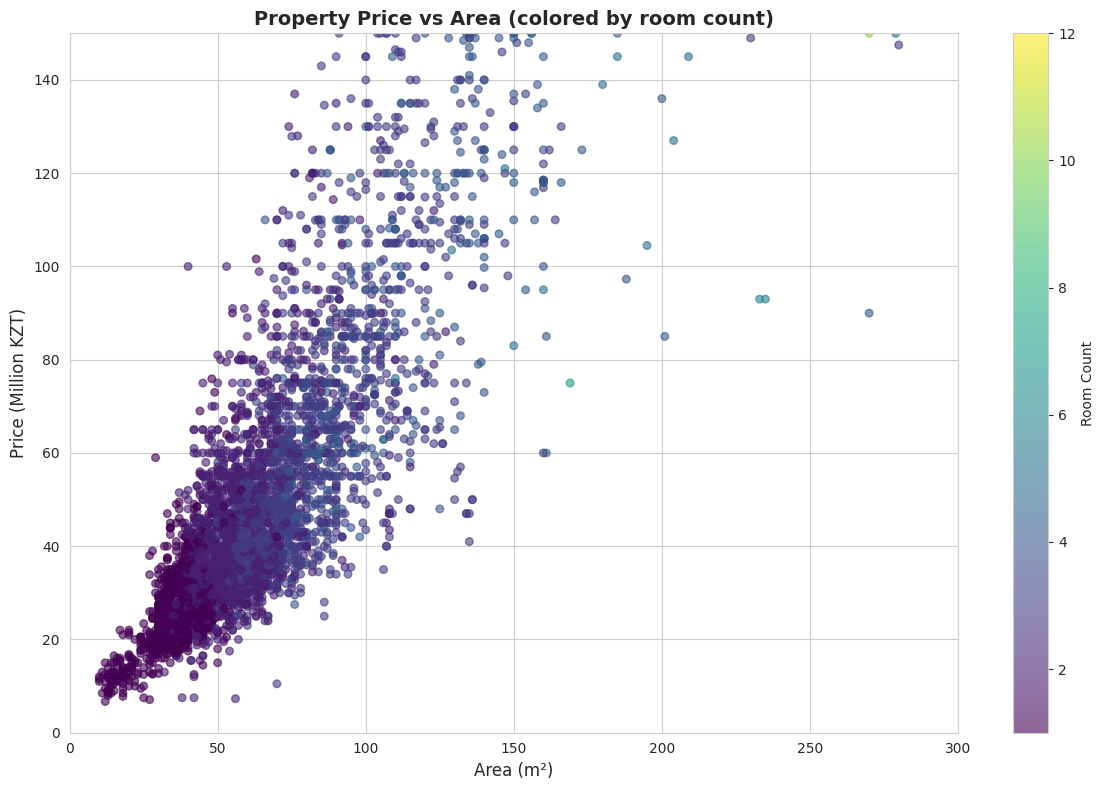

In [21]:
plt.figure(figsize=(12, 8))
sample = listings.sample(min(5000, len(listings)))
scatter = plt.scatter(sample['quadrature'], sample['price']/1000000,
                     c=sample['room_count'], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Room Count')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (Million KZT)', fontsize=12)
plt.title('Property Price vs Area (colored by room count)', fontsize=14, fontweight='bold')
plt.xlim(0, 300)
plt.ylim(0, sample['price'].quantile(0.95)/1000000)
plt.tight_layout()
plt.show()

## Visualization 3: Price Distribution by Room Count

/tmp/ipython-input-1481677938.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(room_data, labels=room_labels)


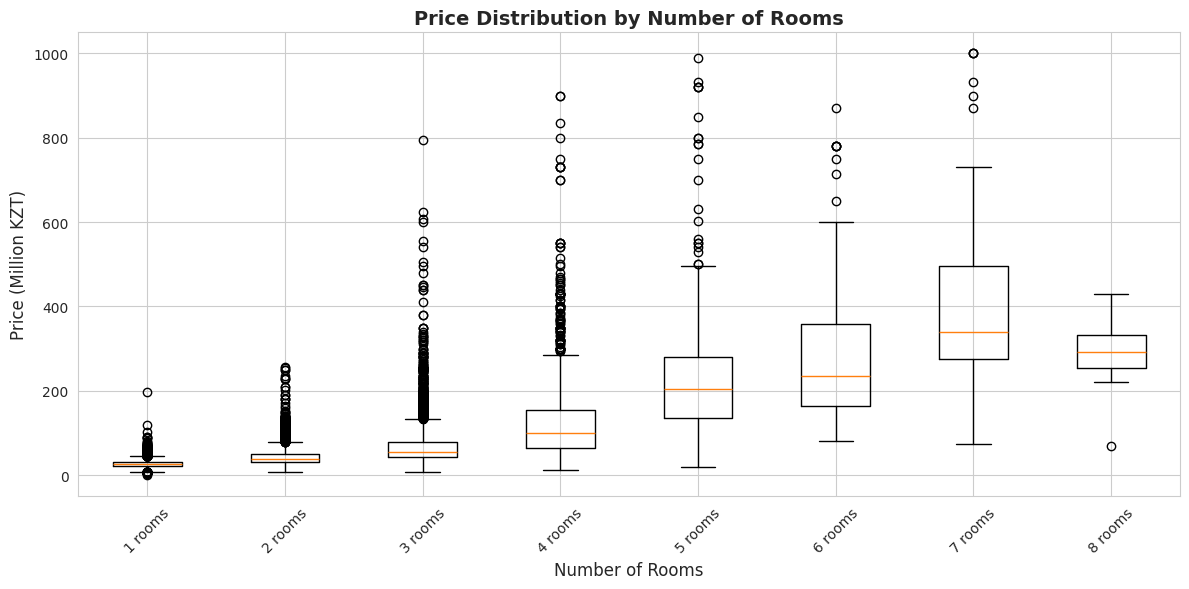

In [22]:
plt.figure(figsize=(12, 6))
room_data = []
room_labels = []
for room in sorted(room_stats['room_count'].unique()):
    if room <= 10:
        data = listings[listings['room_count'] == room]['price'] / 1000000
        if len(data) > 10:
            room_data.append(data)
            room_labels.append(f'{int(room)} rooms')

plt.boxplot(room_data, labels=room_labels)
plt.ylabel('Price (Million KZT)', fontsize=12)
plt.xlabel('Number of Rooms', fontsize=12)
plt.title('Price Distribution by Number of Rooms', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 4: Correlation Heatmap

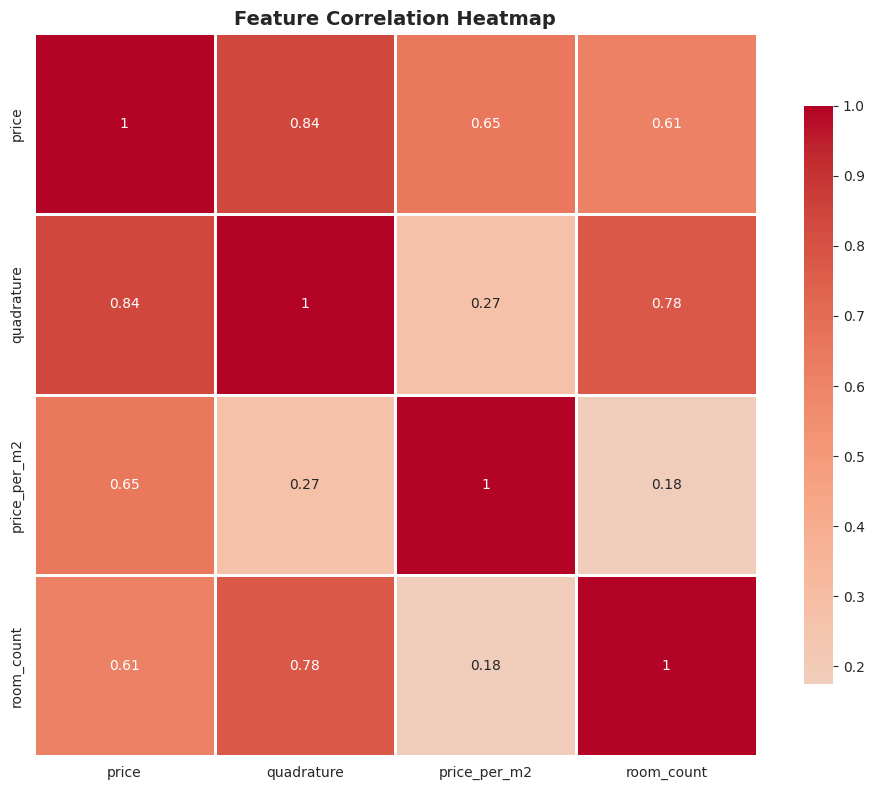

In [23]:
plt.figure(figsize=(10, 8))
corr_data = listings[['price', 'quadrature', 'price_per_m2', 'room_count']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualization 5: Value Score Distribution

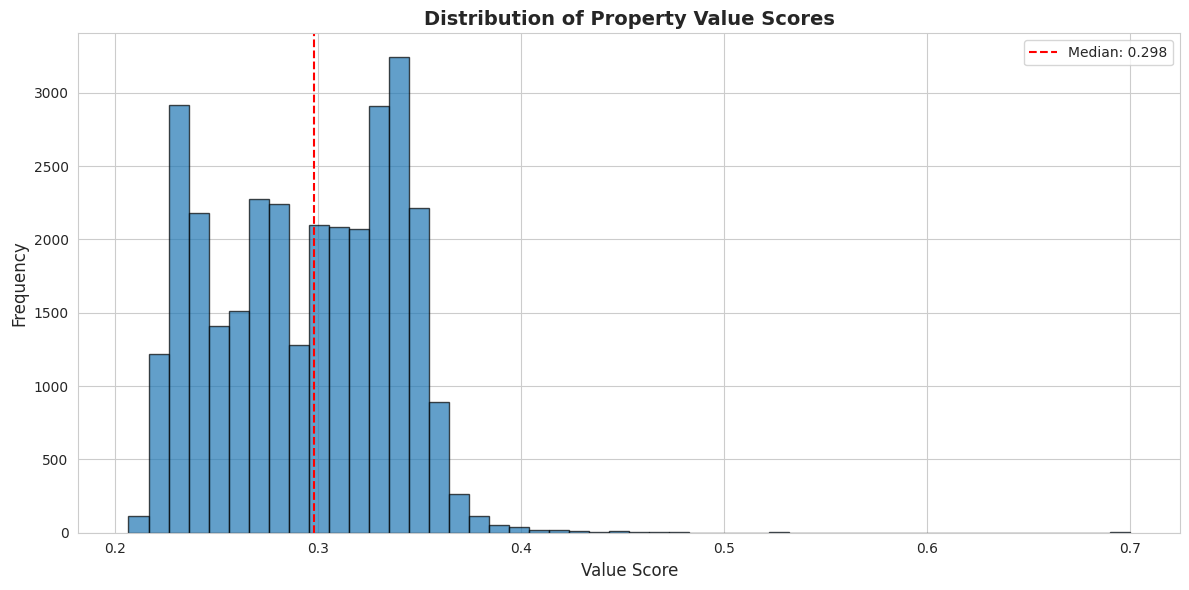

All visualizations displayed successfully!


In [24]:
plt.figure(figsize=(12, 6))
plt.hist(listings['value_score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Value Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Property Value Scores', fontsize=14, fontweight='bold')
plt.axvline(listings['value_score'].median(), color='red', linestyle='--',
            label=f'Median: {listings["value_score"].median():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print("All visualizations displayed successfully!")